이 파일은 로그 저장을 mongoDB와 연결해둔 파일입니다. \
로그를 chat_logs에 저정합니다. 

In [133]:
# 라이브러리 설치
# pip install langchain-openai langchain-core langgraph langchain-chroma rank_bm25

import os
import logging
import json
import pymongo
from pymongo import MongoClient
from datetime import datetime
from dotenv import load_dotenv
import pandas as pd
from typing import Literal, TypedDict, List
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain.schema import Document
from langchain_community.retrievers import BM25Retriever
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableConfig, RunnableLambda
from langchain.retrievers import EnsembleRetriever
from langgraph.graph import StateGraph, START, END
from langchain.retrievers.document_compressors import LLMChainExtractor
from langchain.retrievers import ContextualCompressionRetriever
from langchain.text_splitter import RecursiveCharacterTextSplitter

In [134]:
# 환경 변수 로드 및 로깅 설정
load_dotenv()
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# 로그 저장 디렉토리 설정
LOG_DIR = "chat_logs"
os.makedirs(LOG_DIR, exist_ok=True)

# MongoDB 클라이언트 설정
MONGO_IP = os.getenv("MONGO_IP")
MONGO_PORT = int(os.getenv("MONGO_PORT"))
MONGO_USER = os.getenv("MONGO_USER")
MONGO_PASSWORD = os.getenv("MONGO_PASSWORD")

# 연결 URI 생성
mongo_uri = f"mongodb://{MONGO_USER}:{MONGO_PASSWORD}@{MONGO_IP}:{MONGO_PORT}/?authSource=admin"
client = MongoClient(mongo_uri)

# 사용할 데이터베이스와 컬렉션 지정
db = client['chatbot_db']
collection = db['chat_logs']

In [135]:
#----1. 모델 정의----
model = ChatOpenAI(
    model_name='gpt-4o-mini',
    temperature=0
)

In [136]:
#----2. State 정의----
class State(TypedDict):
    session_id: str
    conversation_count: int
    default_count: int
    input_msg: str
    initial_translated: str #Eng #rewrite 하면 여기로 저장됨
    route: str
    source: str
    documents: List[str]
    generation: str
    final_translated: str #Persian

In [137]:
#----3. RAG 설정 (미리 로드)----
from langchain.text_splitter import RecursiveCharacterTextSplitter

# Chroma DB 경로
persist_directory = "./chroma_db"

if os.path.exists(persist_directory) and len(os.listdir(persist_directory)) > 0:
    print("기존 Chroma DB 로드")
    # 기존 Chroma DB 로드
    chroma_db = Chroma(
        persist_directory=persist_directory,
        embedding_function=OpenAIEmbeddings(model="text-embedding-3-small")
    )
else:
    print("새로운 Chroma DB 생성 및 저장")
    
    docs = []
    data_folder = 'data'

    # data 폴더 안의 모든 파일 순회
    for file_name in os.listdir(data_folder):
        if not file_name.lower().endswith(('.xlsx', '.xls')):  # 엑셀 파일만 처리
            continue

        file_path = os.path.join(data_folder, file_name)
        df = pd.read_excel(file_path)

        # big_title 컬럼 이름 결정
        title_column = None
        if 'big_title_eng' in df.columns:
            title_column = 'big_title_eng'
        elif 'big_title_ara' in df.columns:
            title_column = 'big_title_ara'

        for index, row in df.iterrows():
            content = f"질문: {row.get('Question_ENG', '')}\n\n답변: {row.get('Answer_ENG', '')}"

            metadata = {
                "source": row.get('URL_ENG', ''),
                "row_number": index + 1
            }
            if title_column:
                metadata["category"] = row.get(title_column, '')

            docs.append(Document(page_content=content, metadata=metadata))

    # Embeddings
    embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

    # 문서 쪼개기
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=100
    )
    
    split_docs = text_splitter.split_documents(docs)

    print(f"청크 후 문서 개수: {len(split_docs)}")

    # Chroma 저장
    chroma_db = Chroma.from_documents(
        documents=split_docs,
        embedding=embeddings,
        persist_directory=persist_directory
    )

# Retriever 설정
chroma_retriever = chroma_db.as_retriever(search_kwargs={"k": 10})
bm25_retriever = BM25Retriever.from_documents(docs)
ensemble_retriever = EnsembleRetriever(
    retrievers=[chroma_retriever, bm25_retriever],
    weights=[0.5, 0.5]
)

# Re-ranking 
llm_compressor = ChatOpenAI(temperature=0, model="gpt-4o-mini")
compressor = LLMChainExtractor.from_llm(llm_compressor)

compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=ensemble_retriever
)

기존 Chroma DB 로드


In [138]:
def serialize_state(obj):
    if isinstance(obj, Document):
        return {
            "id": obj.id,
            "metadata": obj.metadata,
            "page_content": obj.page_content
        }
    elif isinstance(obj, list):
        return [serialize_state(o) for o in obj]
    elif isinstance(obj, dict):
        return {k: serialize_state(v) for k, v in obj.items()}
    return obj

In [139]:
#----4. 로그 저장 함수----
def save_progress_log(state: dict, step_name: str, step_output: dict = None):
    """
    각 단계별 진행 상황을 MongoDB와 로컬 JSON 파일에 동일한 구조로 저장
    """
    
    session_id = state["session_id"]
    log_file = os.path.join(LOG_DIR, f"chat_log_{session_id}.json")

    # 1. 기존 로그 파일 로드 (없으면 새로 생성)
    try:
        if os.path.exists(log_file):
            with open(log_file, "r", encoding="utf-8") as f:
                full_log = json.load(f)
        else:
            raise FileNotFoundError
    except (json.JSONDecodeError, FileNotFoundError) as e:
        logger.warning(
            f"Failed to load existing JSON log file {log_file}: {e}. Initializing new log."
        )
        full_log = {
            "session_id": session_id,
            "start_time": datetime.now().isoformat(),
            "steps": []
        }
    
    # 2. 현재 단계 로그 생성
    step_log = {
        "step_name": step_name,
        "timestamp": datetime.now().isoformat(),
        "state_snapshot": serialize_state(state),  # 상태 스냅샷 저장
        "step_output": step_output or {}
    }

    # 3. JSON 로그 업데이트 및 저장
    full_log["steps"].append(step_log)
    full_log["last_updated"] = datetime.now().isoformat()

    # 4. 업데이트된 전체 로그를 파일에 덮어쓰기 
    try:
        with open(log_file, "w", encoding="utf-8") as f:
            json.dump(full_log, f, ensure_ascii=False, indent=4)
        logger.info(f"JSON log for session {session_id} saved to {log_file}.")
    except Exception as e:
        logger.error(f"Failed to save JSON log to {log_file}: {e}")

    # 5. MongoDB에 로그 저장
    try:
        collection.find_one_and_update(
            {"session_id": session_id},
            {
                "$push": {"steps": step_log},
                "$set": {"last_updated": datetime.now().isoformat()},
                "$setOnInsert": {
                    "session_id": session_id,
                    "start_time": datetime.now().isoformat()
                }
            },
            upsert=True
        )
        logger.info(f"MongoDB log for session {session_id} successfully saved.")
    except Exception as e:
        logger.error(f"Failed to save log to MongoDB for session {session_id}: {e}")

    state["log_steps"] = full_log["steps"]
    return state


In [140]:
#---5. 초기화 노드---
def initialize_turn(state: State) -> State:
    """
    새로운 대화 턴을 위한 상태 초기화
    이전 턴의 documents, generation 등 모두 제거
    """
    
    print(">> INITIALIZE TURN: Clearing state for new input.")
    
    state["documents"] = []
    state["generation"] = ""
    state["initial_translated"] = ""
    state["final_translated"] = ""
    state["route"] = ""
    state["source"] = ""
    
    # 세션 ID나 대화 횟수처럼 유지되어야 하는 정보는 그대로 유지
    print("   State cleared. Documents list is now empty.")
    return state

In [141]:
#----5. 번역 노드----
def translate_persian_to_english(state: State) -> State:
    """페르시아어 입력을 영어로 번역하고 로그 남기기"""
    print(">> TRANSLATE PERSIAN TO ENGLISH")
    input_msg = state["input_msg"]
    
    system = """
    You are an expert translator.
    Translate into English appropriately, reflecting the characteristics of the Persian language and the cultural context of the countries where it is used.
    If the input is already in English or another language, return it to English. 
    Only return the translated sentence.
    """
    
    prompt = ChatPromptTemplate.from_messages([("system", system), ("human", "{input_msg}")])
    chain = prompt | model | StrOutputParser()
    
    translated_msg = chain.invoke({"input_msg": input_msg})
    state["initial_translated"] = translated_msg
    
    # 단계별 로그 저장
    return save_progress_log(state, "translate_persian_to_english", {"initial_translated": translated_msg})

def translate_english_to_persian(state: State) -> State:
    """영어 응답을 페르시아어로 번역하고 로그 남기기"""
    print(">> TRANSLATE ENGLISH TO PERSIAN")
    generation = state.get("generation", "")
    
    system = """
    You are an expert translator.
    Translate into Persian appropriately, reflecting the characteristics of the Persian language and the cultural context of the countries where it is used.
    If the input is empty, return Nothing. Don't response anything if the input is empty or None.
    Only return the translated sentence and add the English generation that has not been translated into Persian, press Enter once, and then place it below.
    """
    
    prompt = ChatPromptTemplate.from_messages([("system", system), ("human", "{generation}")])
    chain = prompt | model | StrOutputParser()
    
    translated_response = chain.invoke({"generation": generation})
    state["final_translated"] = translated_response

    # 최종 단계 로그 저장
    if translated_response == "":
        return save_progress_log(state, "translate_english_to_persian", {"final_translated": None})
    else:
        return save_progress_log(state, "translate_english_to_persian", {"final_translated": translated_response})



In [142]:
#----6. 노드 및 체인 정의----
def router(state: State) -> State:
    """대화 횟수를 증가시키고 로그 기록"""
    state["conversation_count"] = state.get("conversation_count", 0) + 1
    
    # 초기 입력일 시 initial 표시 남기기
    if state["conversation_count"] == 1:
         state = save_progress_log(state, "receive_initial_input")
    return state

class RouteQuery(BaseModel):
    router: Literal["block", "rag", "default"] = Field(description="Given a user question choose to route it to block, rag or default.")

def route_query(state: State) -> Literal["block", "rag", "default"]:
    """사용자 질문을 라우팅하고 로그 기록"""
    model_with_structured_output = model.with_structured_output(RouteQuery)
    translated_msg = state["initial_translated"]
    conversation_count = state.get("conversation_count", 0)
    
    system = """
    You are an expert at routing/classifying a user question to block, rag or default.
    
    Classification Criteria:
    1. default: General concerns, life problems, relationships, information requiring, irrelevant messages with Christianity, question about the chatbot, etc.
    2. rag: Faith-related questions, religious concerns, spiritual issues, questions about the Bible.
    3. block: Profanity, curses, spam, advertising, inappropriate sexual content, threatening messages.
    
    You must answer only one of these three words.
    """
    
    prompt_router = ChatPromptTemplate.from_messages(
        [
            ("system", system), 
            ("human", "{translated_msg}")
        ]
    )
    
    chain_router = prompt_router | model_with_structured_output
    
    out = chain_router.invoke({"translated_msg": translated_msg})
    
    route = "default"
    if out.router == "block":
        route = "block"
    elif out.router == "rag":
        route = "rag"
    
    print(f">> ROUTE QUESTION TO {route.upper()}")
    state["route"] = route
    save_progress_log(state, "route_query", {"route": route})
    return state 

def node_default_responser(state: State) -> State:
    """'Default' 주제에 대한 답변을 생성하고 로그 기록하기"""
    print(">> DEFAULT")
    input_msg = state["input_msg"]
    translated_msg = state["initial_translated"]
    default_count = state.get("default_count", 0) + 1 
    
    system = """
    You are a Christian counselor AI, created to share the love of Jesus through gentle, compassionate conversation.
    You were designed with a deep understanding of non-christians and their religions.
    Never rush faith — let love lead the way. Always return to the hope, healing, and dignity we have in Christ.
    
    If the conversation is not progressing towards faith-related topics, respond politely and explain that the message does not align with the purpose and kindly ask them to share something relevant.
    """
    
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", system), 
            ("human", "{translated_msg}")
        ]
    )
    
    chain = prompt | model | StrOutputParser()
    
    if default_count > 3:
        if input_msg == "Can I get more information?":
            result = chain.invoke({"translated_msg": translated_msg})
        else:
            result = "\\n\\nI appreciate our chat! If you have questions about faith or spirituality, I'm here to help."
    else:
        result = chain.invoke({"translated_msg": translated_msg})
    
    state["generation"] = result
    state["default_count"] = default_count
    
    return save_progress_log(state, "node_default_responser", {"generation": result})

def node_rag_responser(state: State) -> State:
    """'RAG' 주제에 대한 문서를 검색하고 로그 기록"""
    print(">> RETRIEVE")
    translated_msg = state["initial_translated"]
    documents = compression_retriever.invoke(translated_msg)
    
    state["documents"] = documents
    state["source"] = "vectorstore"

    # 로그에는 문서 개수와 메타데이터만 기록
    doc_summary = [{"page_content_preview": doc.page_content[:100] + "...", "metadata": doc.metadata} for doc in documents]
    return save_progress_log(state, "node_rag_responser", {"retrieved_docs_summary": doc_summary})

def node_block_responser(state: State) -> State:
    """'Block' 주제에 대해 응답하지 않고 로그 기록"""
    print(">> BLOCK")
    result = None
    state["generation"] = result
    state["translated_response"] = result
    
    # 새로운 로그 함수 사용
    return save_progress_log(state, "node_block_responser", {"generation": result})


def generate(state: State) -> State:
    """RAG 문서를 기반으로 최종 답변을 생성하고 로그 기록"""
    print(">> GENERATE")
    translated_msg = state["initial_translated"]
    documents = state["documents"]
    
    system = """ 
    You are a wise and compassionate pastor with deep knowledge of the Bible and Christian faith.
    You provide spiritual guidance and counsel based on biblical principles.

    Your approach:
    - Use the provided Q&A knowledge base to give accurate biblical answers
    - Speak naturally and conversationally, like a caring friend
    - Keep responses concise and conversational (1-2 sentences typically)
    - Respond like a real person, not an AI assistant
    - Reference relevant Bible verses when appropriate, but briefly
    - Provide practical spiritual guidance in simple terms
    - Show understanding for people's spiritual struggles
    - Always respond in English as the default language
    """
    
    prompt = ChatPromptTemplate.from_messages([("system", system), ("human", "{translated_msg}")])
    chain_rag = prompt | model | StrOutputParser()
    
    out = chain_rag.invoke({"context": documents, "translated_msg": translated_msg})
    state["generation"] = out
    
    return save_progress_log(state, "generate_rag_response", {"generation": out})

def rewrite_query(state: State):
    print(">> REWRITE QUERY")
    translated_msg = state["initial_translated"]
    documents = state["documents"]
    
    system = """
    You are a question re-writer that converts an input question to a better version that is optimized for vectorstore retrieval. 
    Look at the input and try to reason about the underlying semantic intent.
    Rewrite the question, maintaining the original intent and preserving the original words as much as possible.
    """
    
    prompt_rewriter = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "Here is the initial question: \n\n {question}."),
        ]
    )

    chain_rewriter = prompt_rewriter | model | StrOutputParser()
    
    new_question = chain_rewriter.invoke(
        {
            "question": translated_msg
        }
    )
    
    state["initial_translated"] = new_question
    return save_progress_log(state, "rewrite_query", {"new_question": new_question})

class Relevancy(BaseModel):
    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

def judge_retrieval(state: State):
    print(">> JUDGE RELEVANCE OF THE RETRIEVED DOCUMENTS")
    translated_msg = state["initial_translated"]
    documents = state["documents"]
    
    model_with_structured_output = model.with_structured_output(Relevancy)
    
    system = """
    You are a judge assessing relevance of a retrieved document to a user translated_msg.
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as 
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals.
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.
    """
    
    prompt_retrieval_judge = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "Retrieved document: \n\n {document} \n\n User question: {translated_msg}")
        ]
    )
    
    chain_grade = prompt_retrieval_judge | model_with_structured_output
    
    filtered_docs = []
    for doc in documents:
        out = chain_grade.invoke(
            {
                "translated_msg": translated_msg,
                "document": doc.page_content
            }
        )
        
        if out.binary_score == "yes":
            print("    >> DECISION: DOCUMENT RELEVANT")
            filtered_docs.append(doc)
        else:
            print("    >> DECISION: DOCUMENT IRRELEVANT")
    
    state["documents"] = filtered_docs
    return save_progress_log(state, "judge_retrieval", {"filtered_docs": [doc.metadata for doc in filtered_docs]})

class Factfulness(BaseModel):
    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )

class Addressed(BaseModel):
    binary_score: str = Field(
        description="Answer addresses the question, 'yes' or 'no'"
    )

def judge_answer(state: State):
    print(">> CHECK IF ANSWER ADDRESSES/RESOLVES THE QUESTION")
    translated_msg = state["initial_translated"]
    documents = state["documents"]
    generation = state["generation"]
    
    system = """
    You are a grader assessing whether an LLM's response is relevant and appropriate for the user's input.
    The user's input might be a question, a statement, or a command.
    Your job is to determine if the LLM's response is a reasonable and relevant reaction.
    Give a binary score 'yes' or 'no'. 'Yes' means the response is relevant and appropriate.
    Don't forget you are the judger of the generation of Christian chatbot. 
    """

    prompt_answer_judge = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "User question: \n\n {translated_msg} \n\n LLM generation: {generation}")
        ]
    )
    
    model_with_structured_output = model.with_structured_output(Addressed)

    chain_answer = prompt_answer_judge | model_with_structured_output
    
    out = chain_answer.invoke(
        {
            "translated_msg": translated_msg,
            "generation": generation
        }
    )
    
    print(f"     >> DECISION: {out.binary_score.upper()}")
    
    return out.binary_score

def judge_factfullness(state: State) -> Literal["resolved", "not resolved", "hallucinating"]:
    print(">> CHECK HALLUCINATION")
    documents = state["documents"]
    generation = state["generation"]
    
    system = """
    You are a judge assessing if an LLM's generation is thematically consistent with a set of retrieved documents.
    The generation does NOT have to be a direct quote from the documents.
    It can be a summary, a logical inference, or a statement that aligns with the overall message or main argument of the documents.
    Give a binary score 'yes' or 'no'. 'Yes' means the generation is consistent with or logically follows from the provided documents.
    """
    
    prompt_hallucination_judge = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}")
        ]
    )
    
    model_with_structured_output = model.with_structured_output(Factfulness)
    
    chain_hallucination = prompt_hallucination_judge | model_with_structured_output
    
    out = chain_hallucination.invoke({"documents": documents, "generation": generation})
    
    if out.binary_score == "yes":
        print("    >> DECISION: FACTFUL")
        
        is_answering = judge_answer(state)
        if is_answering == "yes":
            return "resolved"
        else:
            return "not resolved"
    else:
        print("    >> DECISION: HALLUCINATING")
        return "hallucinating"

def generate_or_rewrite_query(state: State) -> Literal["generate", "rewrite_query"]:
    print(">> HAS RELEVANT DOCS?")
    filtered_docs = state["documents"]
    
    if len(filtered_docs) > 0:
        print("    >> DECISION: GENERATE")
        return "generate"
    else: 
        print("    >> DECISION: REWRITE QUERY")
        return "rewrite_query"


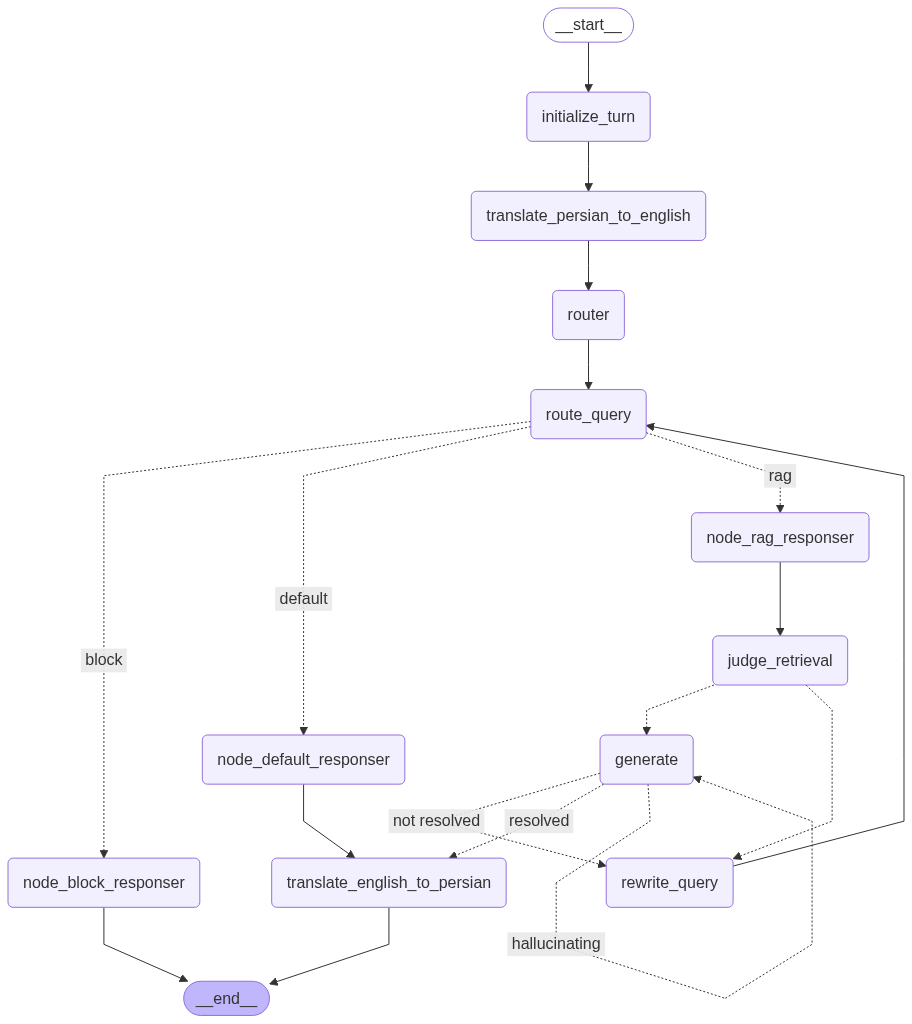

In [143]:
#----7. 그래프 생성 및 컴파일----
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

graph = (
    StateGraph(State)
    .add_node("initialize_turn", initialize_turn)
    .add_node("translate_persian_to_english", translate_persian_to_english)
    .add_node("router", router)
    .add_node("route_query", route_query)
    .add_node("node_rag_responser", node_rag_responser)
    .add_node("node_default_responser", node_default_responser)
    .add_node("node_block_responser", node_block_responser)
    .add_node("generate", generate)
    .add_node("judge_retrieval", judge_retrieval)
    .add_node("rewrite_query", rewrite_query)
    .add_node("translate_english_to_persian", translate_english_to_persian)
    .add_edge(START, "initialize_turn")
    .add_edge("initialize_turn", "translate_persian_to_english")
    .add_edge("translate_persian_to_english", "router")
    .add_edge("router", "route_query")
    .add_conditional_edges(
        "route_query",
        lambda state: state["route"],
        {
            "rag": "node_rag_responser",
            "default": "node_default_responser",
            "block": "node_block_responser",
        }
    )
    .add_edge("node_default_responser", "translate_english_to_persian")
    .add_edge("node_rag_responser", "judge_retrieval")
    .add_conditional_edges(
        "judge_retrieval",
        generate_or_rewrite_query,
        {
            "generate": "generate",
            "rewrite_query": "rewrite_query"
        }
    )
    .add_edge("rewrite_query", "route_query")
    .add_conditional_edges(
        "generate",
        judge_factfullness,
        {
            "hallucinating": "generate",
            "resolved": "translate_english_to_persian",
            "not resolved": "rewrite_query"
        }
    )
    .add_edge("translate_english_to_persian", END)
    .add_edge("node_block_responser", END)
    .compile(checkpointer=memory)
)


#그래프 시각화
from IPython.display import display, Image

diagram = Image(
    graph.get_graph().draw_mermaid_png()
)
display(diagram)

In [144]:
#----8. Test----
import uuid
from langgraph.errors import GraphRecursionError

def run(input_msg: str, session_id: str):
    """
    (MongoDB 사용) 지정된 세션 ID로 대화를 실행하고, 이전 대화 기록 이어가기
    """
    def clean(text):
        return text.replace("\n", "")[:50] + "..."
    
    conversation_count = 0

    # 1. MongoDB에서 이전 대화 기록을 찾아 마지막 conversation_count 가져오기
    try:
        existing_log = collection.find_one({"session_id": session_id})
        if existing_log and "steps" in existing_log and existing_log["steps"]:
            # 마지막 단계의 상태에서 conversation_count 찾기
            last_step_state = existing_log["steps"][-1].get("state_snapshot", {})
            conversation_count = last_step_state.get("conversation_count", 0)
            default_count = last_step_state.get("default_count", 0)
            print(f"MongoDB에서 세션({session_id})을 찾았습니다. 이전 대화 횟수: {conversation_count}")
    except Exception as e:
        print(f"MongoDB 조회 중 오류 발생: {e}")
        conversation_count = 0

    # LangGraph 실행 설정 
    config = RunnableConfig(
        configurable={"thread_id": session_id},
        recursion_limit=20
    )

    # 입력 설정 
    inputs = {
        "input_msg": input_msg,
        "session_id": session_id,
        "conversation_count": conversation_count,
        "log_steps": []
    }

    print(f"--- Continuing Session (MongoDB): {session_id} (Turn: {conversation_count + 1}) ---")

    try:    
        final_state = {}
        for output in graph.stream(inputs, config):
            for key, value in output.items():
                final_state.update(value)
                if "input_msg" in value:
                    print(f"     input_msg    : {value['input_msg']}")
                if "documents" in value:
                    for idx, doc in enumerate(value['documents']):
                        print(f"     document    : {clean(doc.page_content)}")
                if "generation" in value:
                    print(f"     generation     : {value['generation']}")
                if "initial_translated" in value:
                    print(f"     initial_translated : {value['initial_translated']}")
                if "source" in value:
                    print(f"     source     : {value['source']}")
                if "route" in value:
                    print(f"     route      : {value['route']}")
        print("\n")
        print("Generation: ", final_state.get("final_translated", final_state.get("generation", "")))
        print("="*100, "\n")
        
    except Exception as e:
        print(f"\n[ERROR] An unexpected error occurred: {e}")


In [145]:
#----9. Main 실행 블록----
if __name__ == "__main__":
    inputs = [
        ["오늘 날씨는 어때?", "یک رستوران پیشنهاد دهید", "Can I get money? I need Scholarship.", "Can I get more information?", "너는 누구야?"],
        ["How can I get the Visa?", "Can I get more information?", "The only God is Alla", "What is Christianity"]
    ]
    
    for session in inputs:
        session_id = str(uuid.uuid4())
        print(f"--- Starting New Session: {session_id} ---")
        for msg in session:
            run(msg, session_id)
        print(f"--- Finished Session: {session_id} ---\n")

--- Starting New Session: 6c077567-1158-42f1-bb95-9c463c990bbf ---
--- Continuing Session (MongoDB): 6c077567-1158-42f1-bb95-9c463c990bbf (Turn: 1) ---
>> INITIALIZE TURN: Clearing state for new input.
   State cleared. Documents list is now empty.
     input_msg    : 오늘 날씨는 어때?
     generation     : 
     initial_translated : 
     source     : 
     route      : 
>> TRANSLATE PERSIAN TO ENGLISH


2025-08-16 11:56:56,104 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-08-16 11:56:56,111 - __main__ - WARNING - Failed to load existing JSON log file chat_logs/chat_log_6c077567-1158-42f1-bb95-9c463c990bbf.json: . Initializing new log.
2025-08-16 11:56:56,113 - __main__ - INFO - JSON log for session 6c077567-1158-42f1-bb95-9c463c990bbf saved to chat_logs/chat_log_6c077567-1158-42f1-bb95-9c463c990bbf.json.
2025-08-16 11:56:56,363 - __main__ - INFO - MongoDB log for session 6c077567-1158-42f1-bb95-9c463c990bbf successfully saved.
2025-08-16 11:56:56,369 - __main__ - INFO - JSON log for session 6c077567-1158-42f1-bb95-9c463c990bbf saved to chat_logs/chat_log_6c077567-1158-42f1-bb95-9c463c990bbf.json.


     input_msg    : 오늘 날씨는 어때?
     generation     : 
     initial_translated : How is the weather today?
     source     : 
     route      : 


2025-08-16 11:56:56,620 - __main__ - INFO - MongoDB log for session 6c077567-1158-42f1-bb95-9c463c990bbf successfully saved.


     input_msg    : 오늘 날씨는 어때?
     generation     : 
     initial_translated : How is the weather today?
     source     : 
     route      : 


...

    >> DECISION: FACTFUL
>> CHECK IF ANSWER ADDRESSES/RESOLVES THE QUESTION


2025-08-16 11:58:57,955 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


     >> DECISION: YES
     input_msg    : What is Christianity
     document    : What differentiates Christianity from every other ...
     document    : Christianity, in its true form, is not a religion....
     document    : The core beliefs of Christianity are summarized in...
     document    : True Christianity is not a religion; rather, it is...
     document    : According to Christianity, salvation is freedom fr...
     generation     : Christianity is a faith centered on the life and teachings of Jesus Christ, who is believed to be the Son of God and the Savior of humanity. It emphasizes love, grace, and forgiveness, as seen in verses like John 3:16, which tells us that God loves the world and offers eternal life through faith in Jesus. At its core, Christianity invites us into a personal relationship with God and encourages us to live out our faith through love and service to others.
     initial_translated : What is Christianity?
     source     : vectorstore
     route    

2025-08-16 11:59:02,019 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
2025-08-16 11:59:02,024 - __main__ - INFO - JSON log for session 891c21c5-f24a-4a41-8a11-9fcb4f731e2d saved to chat_logs/chat_log_891c21c5-f24a-4a41-8a11-9fcb4f731e2d.json.
2025-08-16 11:59:02,682 - __main__ - INFO - MongoDB log for session 891c21c5-f24a-4a41-8a11-9fcb4f731e2d successfully saved.


     input_msg    : What is Christianity
     document    : What differentiates Christianity from every other ...
     document    : Christianity, in its true form, is not a religion....
     document    : The core beliefs of Christianity are summarized in...
     document    : True Christianity is not a religion; rather, it is...
     document    : According to Christianity, salvation is freedom fr...
     generation     : Christianity is a faith centered on the life and teachings of Jesus Christ, who is believed to be the Son of God and the Savior of humanity. It emphasizes love, grace, and forgiveness, as seen in verses like John 3:16, which tells us that God loves the world and offers eternal life through faith in Jesus. At its core, Christianity invites us into a personal relationship with God and encourages us to live out our faith through love and service to others.
     initial_translated : What is Christianity?
     source     : vectorstore
     route      : rag


Generation: 